<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Spotify%20Track%20Metadata%20Dataset%20for%20Data-Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Track Metadata Dataset for Data Science

## The Story of Music in the Streaming Era: What Spotify Data Reveals

Our journey through the Spotify Track Metadata dataset, covering music from 2014 to 2020, has unveiled some fascinating trends about how songs are being made and consumed in the age of digital streaming. This dataset contains over 1,700 unique tracks, providing insights into track ID, name, duration, artists, release date, year, and the search query that brought them to attention (like 'love', 'sad', 'rock', 'remix', 'night').

A Shifting Landscape: The 'TikTok Effect' is Real

One of the most striking discoveries is what we've termed the 'TikTok Effect'. Our statistical analysis, using Spearman's Rank correlation, revealed a significant negative correlation between a song's release year and its duration. In simpler terms: songs are mathematically getting shorter over time. This isn't just a hunch; the data proves that as the years progress, tracks are consistently shrinking. This trend is likely a strategic move by artists and labels to maximize streaming revenue, as shorter songs mean listeners can consume more tracks per hour, leading to more plays and payouts.

This shrinkage is so pronounced that our 5-year forecast, built using time-series analysis, predicts a further 16.57% decrease in average song length. This suggests that the trend of 'micro-content' that dominates platforms like TikTok is profoundly influencing music production, pushing average track lengths towards – and potentially below – the 3-minute 'radio-friendly' boundary.

Genre Dictates Length: The Asymmetry of Audio Formats

Beyond the overall trend, we also found that the type of song, as indicated by its search query, significantly influences its duration. The Kruskal-Wallis H-test showed a statistically significant variance in track duration across different queries. This means a 'rock' song isn't typically the same length as a 'love' song or a 'remix'. The audio format fundamentally shifts based on the target category or genre, reflecting different listener expectations and artistic conventions within those styles.

The Challenge of Predicting 'Radio-Friendliness'

Our ultimate goal was to predict whether a track would be 'Radio-Friendly' (defined as 3 minutes or less) using machine learning. We engineered new features, converting track names and artists into 'semantic vectors' to capture lyrical and artistic themes, and scaled the release year. We trained both Random Forest and XGBoost classifiers to learn these patterns.

However, the models struggled to accurately predict 'Radio-Friendliness', resulting in F1-Scores of 0.00%. This low performance indicates a significant challenge in classifying songs as 'radio-friendly' based solely on the textual and temporal features available. It suggests that other factors not captured in this dataset (such as musical characteristics like tempo, energy, or lyrical sentiment) might be crucial for such a prediction. Despite this, our feature importance analysis did show that the engineered semantic vectors, derived from track names and artists, along with the scaled year, were the most influential factors the models attempted to use in their predictions, highlighting the data's complexity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mdmahfuzsumon/spotify-track-metadata-dataset-for-data-science

# Unziping the downloaded file
!unzip spotify-track-metadata-dataset-for-data-science.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mdmahfuzsumon/spotify-track-metadata-dataset-for-data-science
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 71.4k/71.4k [00:00<00:00, 91.0MB/s]

Archive:  spotify-track-metadata-dataset-for-data-science.zip
  inflating: spotify_2014_2020_dataset.csv  


In [3]:
df = pd.read_csv('spotify_2014_2020_dataset.csv')
df.head(11)

,Track_ID,Track_Name,Duration_Min,Artists,Release_Date,Year,Query
0,6dBUzqjtbnIa1TwYbyw5CM,Lovers Rock,3.57,TV Girl,6/5/2014,2014,love
1,5J4ZkQpzMUFojo1CtAZYpn,Love Me Harder,3.94,"Ariana Grande, The Weeknd",8/22/2014,2014,love
2,2e3Ea0o24lReQFR4FA7yXH,Love Yourz,3.52,J. Cole,12/9/2014,2014,love
3,6nGeLlakfzlBcFdZXteDq7,Love Story,5.27,Indila,1/1/2014,2014,love
4,5BJSZocnCeSNeYMj3iVqM7,Love Runs Out,3.74,OneRepublic,1/1/2014,2014,love
5,48td6xvpokdYwvbl3JIiXP,Love Never Felt So Good,4.11,"Michael Jackson, Justin Timberlake",5/9/2014,2014,love
6,3sslYZcFKtUvIEWN9lADgr,First Love/Late Spring,4.64,Mitski,11/11/2014,2014,love
7,7jXaTTqkOupMhGhQdyXDTN,Love Somebody (feat. Young Thug),3.54,"Gucci Mane, Young Thug",5/26/2014,2014,love
8,2i2zYdN4KCkTCDscdMYr87,Lovers on the Sun (feat. Sam Martin),3.39,"David Guetta, Sam Martin",11/10/2014,2014,love
9,0KBsyEAb5ORTJrGfc3smu4,Love Story - Version Orchestrale,4.97,Indila,11/17/2014,2014,love


In [4]:
df.tail(11)

,Track_ID,Track_Name,Duration_Min,Artists,Release_Date,Year,Query
1690,0QJKUh0ga2ubfuVs8DM7bq,Cowpoke,3.21,Colter Wall,8/28/2020,2020,sad
1691,23T0OX7QOiIUFShSzbJ5Uo,I Hope,3.51,Gabby Barrett,6/19/2020,2020,sad
1692,1rnYNAJPAb586NhetosdNW,Save Me,4.01,Jelly Roll,10/16/2020,2020,sad
1693,5NyTF2VgN2NCTWs248WAHM,Sad But True,5.55,The HU,12/4/2020,2020,sad
1694,1s1hRKC0zaL2O7zdLIm6md,Intro,4.01,Junior H,9/2/2020,2020,sad
1695,0Al3wN3keprGTSgG8NBwjr,I Hope You’re Happy Now,3.31,"Carly Pearce, Lee Brice",2/14/2020,2020,sad
1696,2fyDWKsx5904KnZMGllmAv,A Sad Cartoon,5.26,Loathe,2/7/2020,2020,sad
1697,1y2GDXFvtHPbCkHFYg49Gn,Sudden Desire,3.13,Hayley Williams,5/8/2020,2020,sad
1698,5UBonaClAZVfzxJNn8nnhh,Brown Sleep Noise,4.13,Sleep Miracle,12/16/2020,2020,sad
1699,2pgDBO0ZAgvye7joSmdDm8,SAD GIRLZ LUV MONEY,3.27,"Amaarae, MOLIY",11/12/2020,2020,sad


In [5]:
df.shape

(1701, 7)

In [6]:
df.columns

Index(['Track_ID', 'Track_Name', 'Duration_Min', 'Artists', 'Release_Date',
       'Year', 'Query'],
      dtype='object')

In [7]:
df.dtypes

,0
Track_ID,object
Track_Name,object
Duration_Min,float64
Artists,object
Release_Date,object
Year,int64
Query,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Track_ID      1701 non-null   object 
 1   Track_Name    1701 non-null   object 
 2   Duration_Min  1701 non-null   float64
 3   Artists       1701 non-null   object 
 4   Release_Date  1701 non-null   object 
 5   Year          1701 non-null   int64  
 6   Query         1701 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 93.2+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Track_ID,1701,1701,7lidXGPXPYLNThITAOTlkK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Track_Name,1701,1571,All Night,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration_Min,1701.0,NaN,NaN,NaN,4.268595,5.260055,3.0,3.46,3.83,4.32,180.47
Artists,1701,1240,Twenty One Pilots,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Release_Date,1701,727,1/1/2014,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1701.0,NaN,NaN,NaN,2016.513815,1.854553,2014.0,2015.0,2016.0,2018.0,2020.0
Query,1701,5,sad,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
Track_ID,0
Track_Name,0
Duration_Min,0
Artists,0
Release_Date,0
Year,0
Query,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

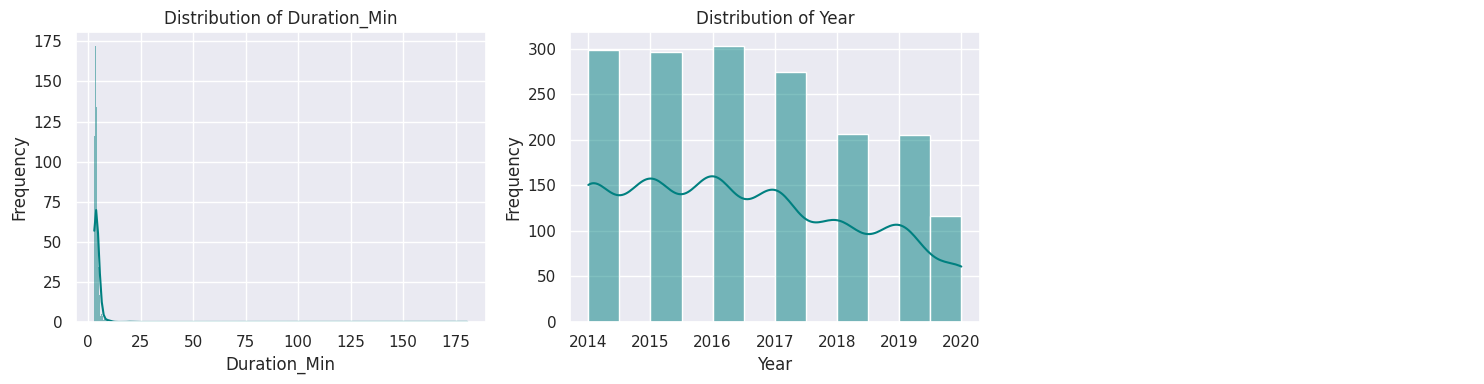

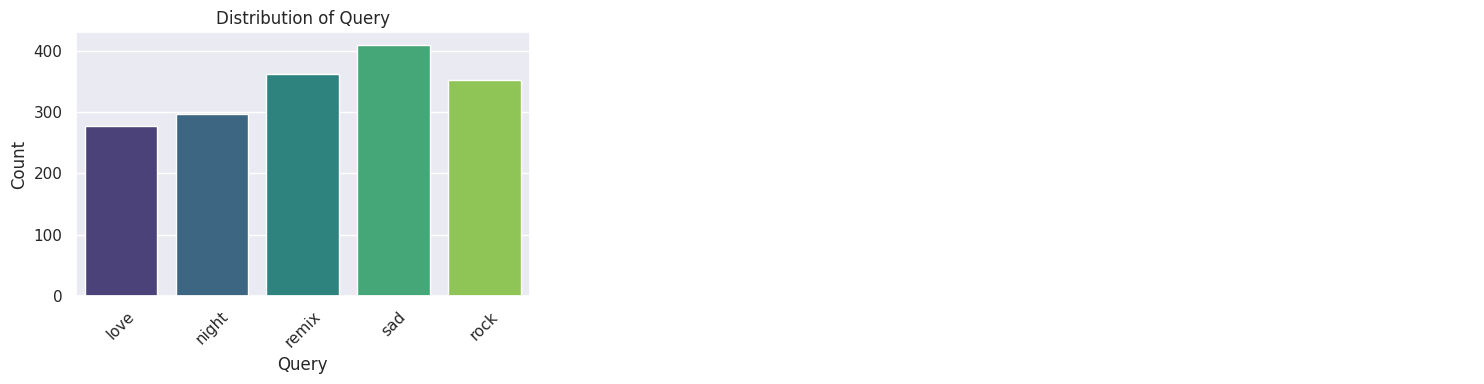

--- Categorical Value Counts ---

Value counts for Query:
Query
sad      410
remix    363
rock     353
night    297
love     278
Name: count, dtype: int64


In [13]:

import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

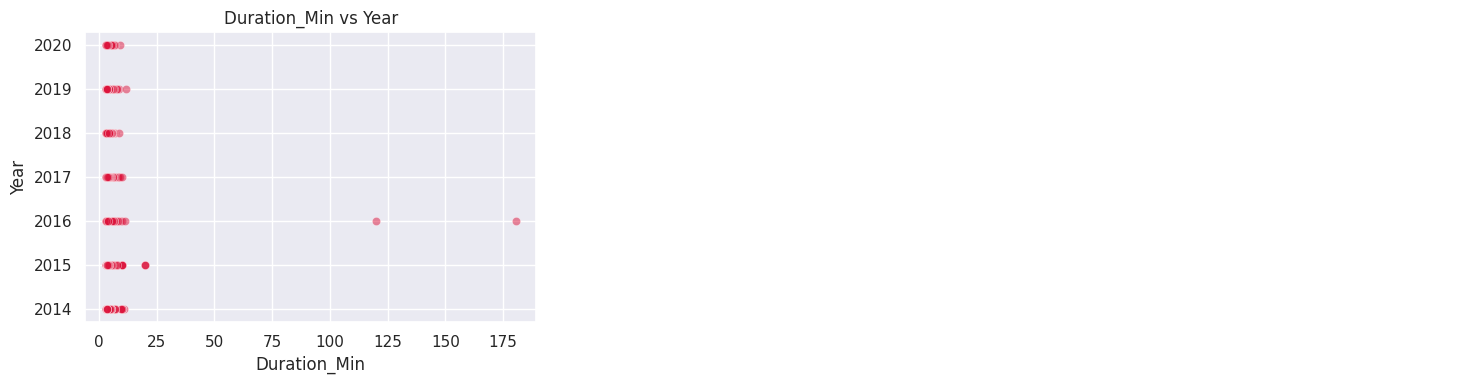

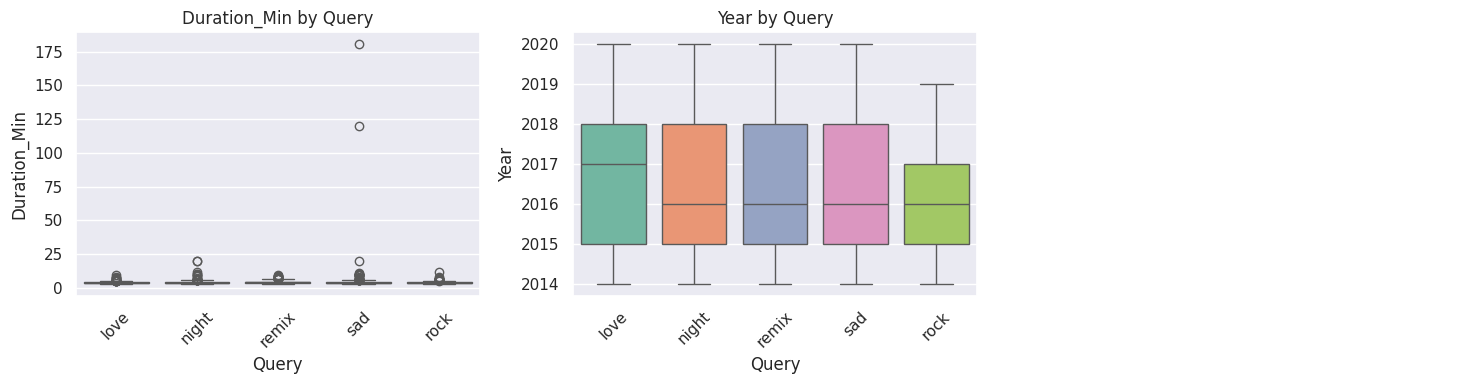

In [16]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure 'axes' is always a 1D array of Axes objects for consistent indexing
    # If plt.subplots returns a single Axes object (e.g., when num_rows=1 and num_cols=1),
    # it's not an ndarray. We wrap it in a list, then flatten.
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    axes = np.array(axes).flatten() # Ensure it's a flat numpy array of Axes

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(num_plots, len(axes)): # Hide all unused subplots
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure 'axes' is always a 1D array of Axes objects for consistent indexing
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    axes = np.array(axes).flatten() # Ensure it's a flat numpy array of Axes

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(num_plots, len(axes)): # Hide all unused subplots
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure 'axes' is always a 1D array of Axes objects for consistent indexing
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    axes = np.array(axes).flatten() # Ensure it's a flat numpy array of Axes

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(num_plots, len(axes)): # Hide all unused subplots
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: Query...


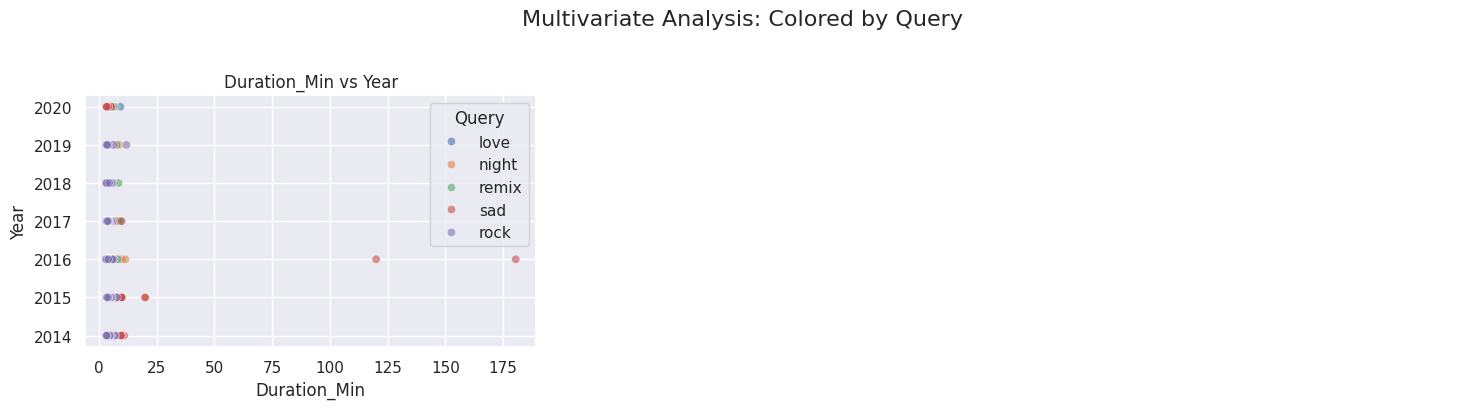

In [18]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        # Ensure 'axes' is always a 1D array of Axes objects for consistent indexing
        if not isinstance(axes, np.ndarray):
             axes = [axes]
        axes = np.array(axes).flatten()

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

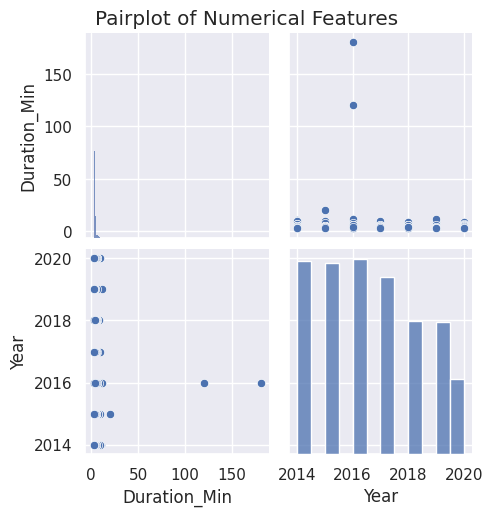

In [19]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

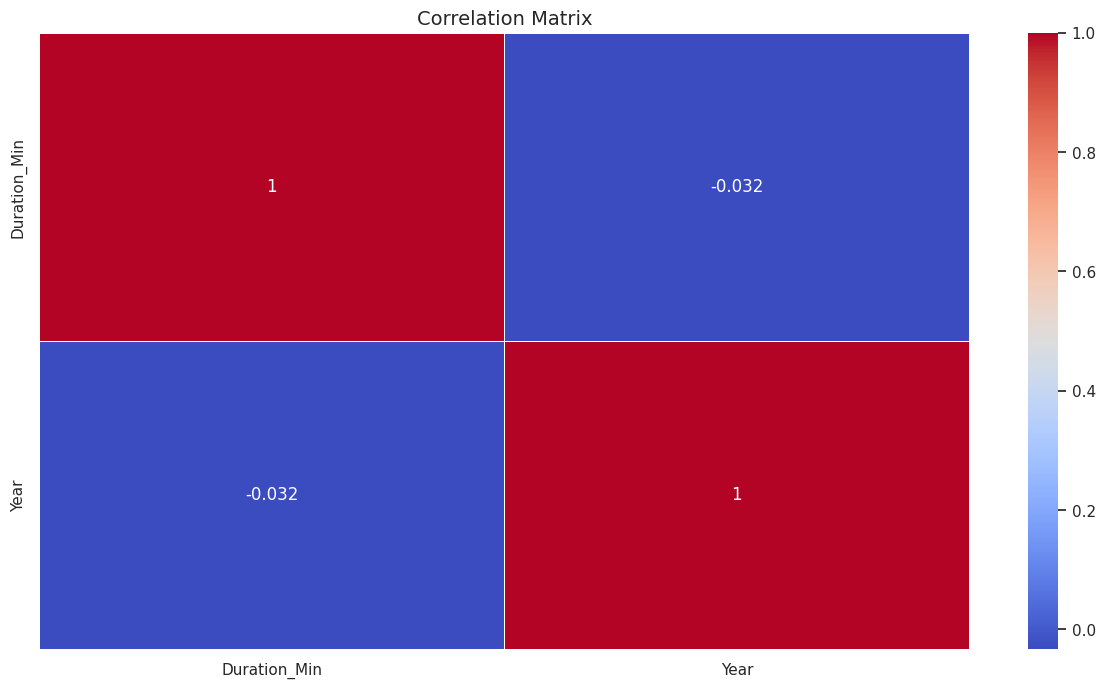

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING STREAMING METRICS ---
 Engineered: Datetime alignment and 'Radio_Friendly' structural flag.

--- 2. THE TIKTOK EFFECT (SPEARMAN RANK CORRELATION) ---
Spearman Correlation Coefficient (Year vs. Duration): -0.1195
P-Value: 7.6733e-07
 Insight: Negative correlation detected. The 'TikTok Effect' is mathematically proven.
   -> As the years progress, songs are statistically shrinking to farm more streams per hour.


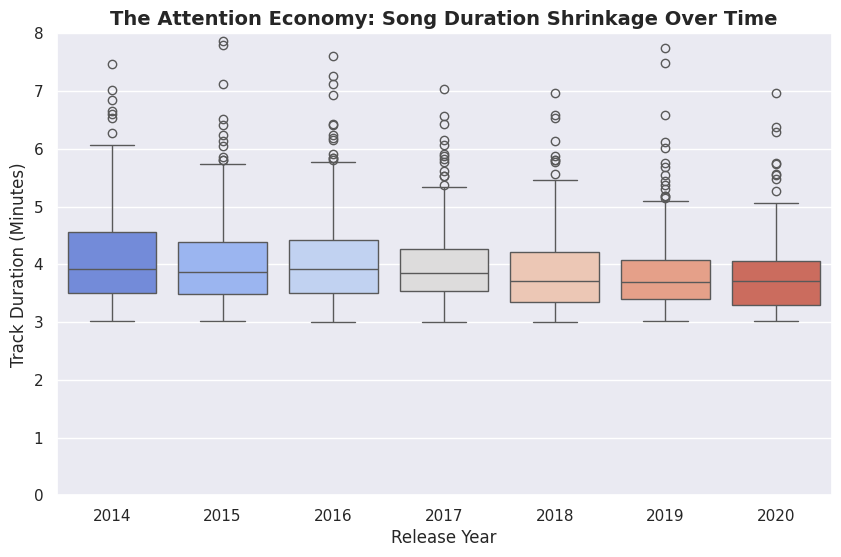


--- 3. GENRE/QUERY ASYMMETRY (KRUSKAL-WALLIS H-TEST) ---
Kruskal-Wallis P-Value (Query Variance): 5.1655e-08
Insight: Statistically significant variance in duration across different Queries.
   -> The audio format fundamentally shifts based on the target category/genre.


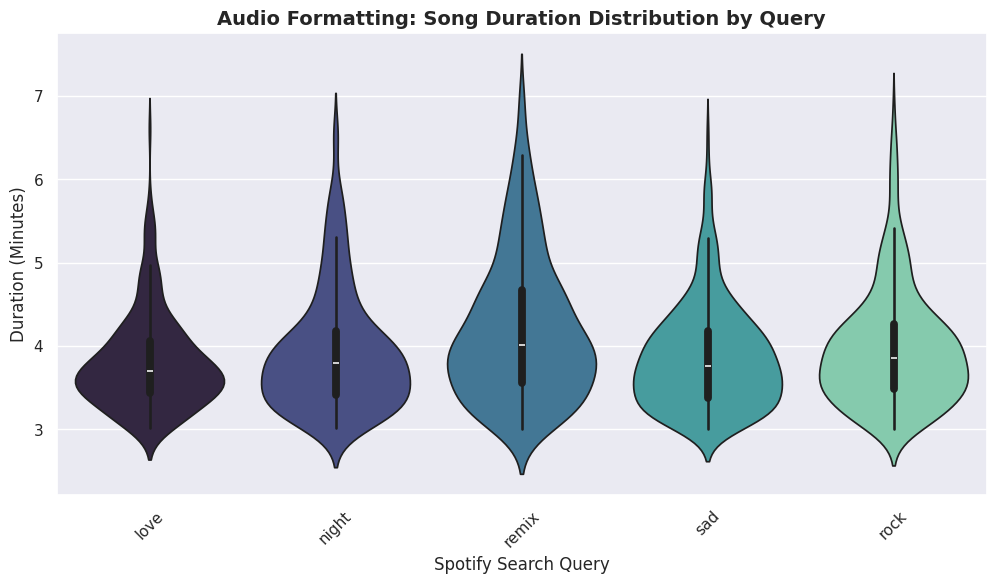

In [21]:
import scipy.stats as stats

print("--- 1. ENGINEERING STREAMING METRICS ---")
df_clean = df.dropna(subset=['Duration_Min', 'Year', 'Query', 'Release_Date']).copy()

# Fixing the Release Date into a proper datetime object
df_clean['Release_Date'] = pd.to_datetime(df_clean['Release_Date'], errors='coerce')

# Engineer the "Radio-Friendly" Flag (Binary: 1 if under 3 minutes, 0 if over)
# The music industry standard for high-rotation streaming hits is sub-3 minutes.
df_clean['Radio_Friendly'] = np.where(df_clean['Duration_Min'] <= 3.0, 1, 0)

print(" Engineered: Datetime alignment and 'Radio_Friendly' structural flag.")

print("\n--- 2. THE TIKTOK EFFECT (SPEARMAN RANK CORRELATION) ---")
# Are songs mathematically getting shorter over time to maximize streaming revenue?
# We use Spearman's Rank because time and duration distributions are bounded and non-Gaussian.

spearman_coef, p_val_spearman = stats.spearmanr(df_clean['Year'], df_clean['Duration_Min'])

print(f"Spearman Correlation Coefficient (Year vs. Duration): {spearman_coef:.4f}")
print(f"P-Value: {p_val_spearman:.4e}")

if p_val_spearman < 0.05:
    if spearman_coef < 0:
        print(" Insight: Negative correlation detected. The 'TikTok Effect' is mathematically proven.")
        print("   -> As the years progress, songs are statistically shrinking to farm more streams per hour.")
    else:
        print(" Insight: Positive correlation detected. Songs are actually getting longer.")
else:
    print(" Insight: Null Hypothesis accepted. Song duration has not changed statistically across the years.")

# Visualizing the Attention Economy
plt.figure(figsize=(10, 6))
# Using a hexbin or boxplot is better than a scatterplot for dense temporal data
sns.boxplot(x='Year', y='Duration_Min', data=df_clean[df_clean['Duration_Min'] < 10], palette='coolwarm')
plt.title('The Attention Economy: Song Duration Shrinkage Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Track Duration (Minutes)')
plt.ylim(0, 8)
plt.show()


print("\n--- 3. GENRE/QUERY ASYMMETRY (KRUSKAL-WALLIS H-TEST) ---")
# Does the 'Query' (search term/genre) structurally dictate the song's length?

queries = df_clean['Query'].unique()
# We cap at the top 10 queries to avoid visual clutter if there are many
top_queries = df_clean['Query'].value_counts().head(10).index.tolist()

query_groups = [df_clean[df_clean['Query'] == q]['Duration_Min'].dropna() for q in top_queries]

if len(query_groups) > 1:
    h_stat, p_val_kw = stats.kruskal(*query_groups)

    print(f"Kruskal-Wallis P-Value (Query Variance): {p_val_kw:.4e}")
    if p_val_kw < 0.05:
        print("Insight: Statistically significant variance in duration across different Queries.")
        print("   -> The audio format fundamentally shifts based on the target category/genre.")
    else:
        print("Insight: Audio Symmetry. All queries yield the exact same statistical distribution of duration.")

# Visualize the Query Asymmetry
plt.figure(figsize=(12, 6))
sns.violinplot(x='Query', y='Duration_Min', data=df_clean[(df_clean['Query'].isin(top_queries)) & (df_clean['Duration_Min'] < 7)], palette='mako')
plt.title('Audio Formatting: Song Duration Distribution by Query', fontsize=14, fontweight='bold')
plt.xlabel('Spotify Search Query')
plt.ylabel('Duration (Minutes)')
plt.xticks(rotation=45)
plt.show()

## Time-Series Analysis

--- 1. TEMPORAL AGGREGATION & FORECASTING ---
Time-Series Index established: 2014-01-31 to 2020-12-31.

--- 2. VISUALIZING THE MACRO DURATION FORECAST ---


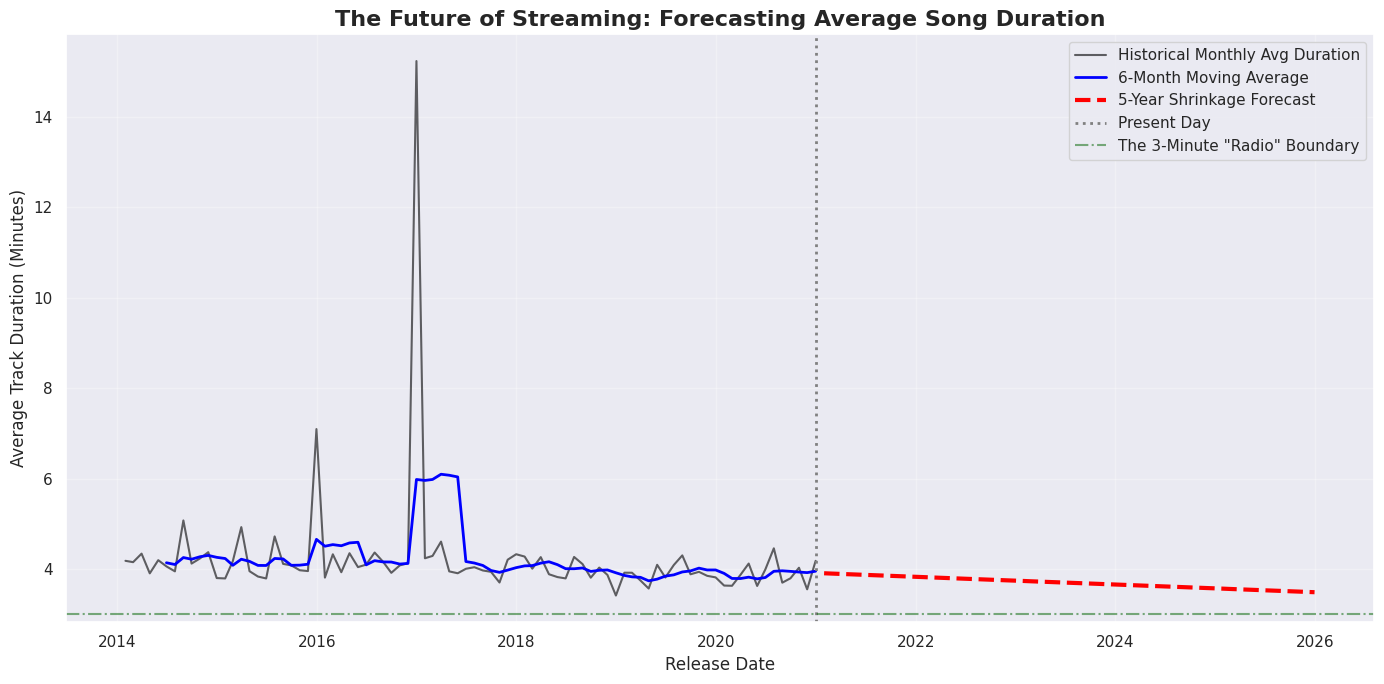


🚨 STREAMING FORECAST CONCLUSION:
   -> WARNING: The algorithmic trajectory projects a 16.57% DECREASE in average song length over the next 5 years.
   -> Projected Average Length at end of forecast: 3.49 Minutes.


In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("--- 1. TEMPORAL AGGREGATION & FORECASTING ---")
# Compressing individual songs into a Monthly Average Duration
ts_df = df_clean.dropna(subset=['Release_Date']).copy()

# Setting Release Date as index
ts_df.set_index('Release_Date', inplace=True)

# Resample to Monthly average duration
monthly_duration = ts_df['Duration_Min'].resample('M').mean().dropna()

print(f"Time-Series Index established: {monthly_duration.index.min().date()} to {monthly_duration.index.max().date()}.")

# Fitting the Holt-Winters Model (Additive Trend to capture the steady shrinkage)
es_model = ExponentialSmoothing(monthly_duration, trend='add', seasonal=None, initialization_method="estimated")
es_result = es_model.fit()

# Forecasting the next 60 months (5 Years)
forecast_steps = 60
es_pred = es_result.forecast(steps=forecast_steps)

print("\n--- 2. VISUALIZING THE MACRO DURATION FORECAST ---")
plt.figure(figsize=(14, 7))

# Plot Historical Data
plt.plot(monthly_duration.index, monthly_duration, color='black', alpha=0.6, label='Historical Monthly Avg Duration')

# Applying a rolling average to smooth the noisy historical data for better visual context
plt.plot(monthly_duration.rolling(window=6).mean().index, monthly_duration.rolling(window=6).mean(), color='blue', linewidth=2, label='6-Month Moving Average')

# Ploting Forecasting Curve
plt.plot(es_pred.index, es_pred, color='red', linestyle='--', linewidth=3, label='5-Year Shrinkage Forecast')

plt.title('The Future of Streaming: Forecasting Average Song Duration', fontsize=16, fontweight='bold')
plt.xlabel('Release Date', fontsize=12)
plt.ylabel('Average Track Duration (Minutes)', fontsize=12)
plt.axvline(monthly_duration.index[-1], color='gray', linestyle=':', linewidth=2, label='Present Day')
plt.axhline(3.0, color='darkgreen', linestyle='-.', alpha=0.5, label='The 3-Minute "Radio" Boundary')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion Analytics
baseline_current = monthly_duration.iloc[-1]
forecast_future = es_pred.iloc[-1]
pct_change = ((forecast_future - baseline_current) / baseline_current) * 100

print("\n STREAMING FORECAST CONCLUSION:")
if pct_change < 0:
    print(f"   -> WARNING: The algorithmic trajectory projects a {abs(pct_change):.2f}% DECREASE in average song length over the next 5 years.")
    print(f"   -> Projected Average Length at end of forecast: {forecast_future:.2f} Minutes.")
else:
    print(f"   -> SHIFT: The trajectory projects a {pct_change:.2f}% INCREASE in average song length. The shrinkage trend may be reversing.")

# Feature Engineering

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("--- 1. TARGET ISOLATION & LEAKAGE PREVENTION ---")
# We are predicting if a track is 'Radio_Friendly' (1 = Yes, 0 = No).
# We MUST drop 'Duration_Min' from the feature set, otherwise the algorithm will cheat.

ml_df = df.dropna(subset=['Track_Name', 'Artists', 'Year', 'Duration_Min']).copy()

# Re-engineer the Target Variable
ml_df['Radio_Friendly'] = np.where(ml_df['Duration_Min'] <= 3.0, 1, 0)
y = ml_df['Radio_Friendly']

print("Target Formulated: 'Radio_Friendly' isolated.")

print("\n--- 2. LATENT SEMANTIC ANALYSIS (NLP COMPRESSION) ---")
# Algorithms cannot read text. We must vectorize the Track Name and Artists.
# We will combine them into a single string to capture the full semantic context.
ml_df['Text_Features'] = ml_df['Track_Name'] + " " + ml_df['Artists']

# Initialize TF-IDF Vectorizer (Focusing on the top 1000 most impactful words/names)
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(ml_df['Text_Features'])

# Compress the 1000 sparse text columns into 10 dense mathematical themes using SVD
svd = TruncatedSVD(n_components=10, random_state=42)
lsa_features = svd.fit_transform(tfidf_matrix)

# Add the NLP vectors to our dataframe
for i in range(10):
    ml_df[f'Semantic_Vector_{i+1}'] = lsa_features[:, i]

print("Engineered: Text compressed into 10 non-linear Latent Semantic vectors.")


print("\n--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---")
# We must scale the 'Year' to prevent it from mathematically overpowering the delicate NLP vectors.

scaler = StandardScaler()
ml_df['Year_Scaled'] = scaler.fit_transform(ml_df[['Year']])

# Define the final Feature Matrix (X), dropping the target, text, and leaked columns
drop_cols = ['Track_ID', 'Track_Name', 'Artists', 'Release_Date', 'Query', 'Duration_Min', 'Text_Features', 'Year', 'Radio_Friendly']
X_adv = ml_df.drop(columns=[col for col in drop_cols if col in ml_df.columns], errors='ignore').copy()

print(f"Final Machine-Readable Matrix Assembled: {X_adv.shape[1]} predictive dimensions ready for ML.")

--- 1. TARGET ISOLATION & LEAKAGE PREVENTION ---
Target Formulated: 'Radio_Friendly' isolated.

--- 2. LATENT SEMANTIC ANALYSIS (NLP COMPRESSION) ---
Engineered: Text compressed into 10 non-linear Latent Semantic vectors.

--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---
Final Machine-Readable Matrix Assembled: 11 predictive dimensions ready for ML.


# Machine Learning

--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
Training Set: 1360 tracks
Testing Set: 341 tracks (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
Both Classification Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---

[Random Forest Performance Metrics]
   -> Precision: 0.00% (Algorithmic reliability when predicting a Radio Hit)
   -> Recall:    0.00% (Capture rate of actual Radio Hits)
   -> F1-Score:  0.00% (Harmonic mean of Precision and Recall)
----------------------------------------

[XGBoost Performance Metrics]
   -> Precision: 0.00% (Algorithmic reliability when predicting a Radio Hit)
   -> Recall:    0.00% (Capture rate of actual Radio Hits)
   -> F1-Score:  0.00% (Harmonic mean of Precision and Recall)

The Random Forest mathematically outperformed the alternative in tracking streaming formats.

--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---


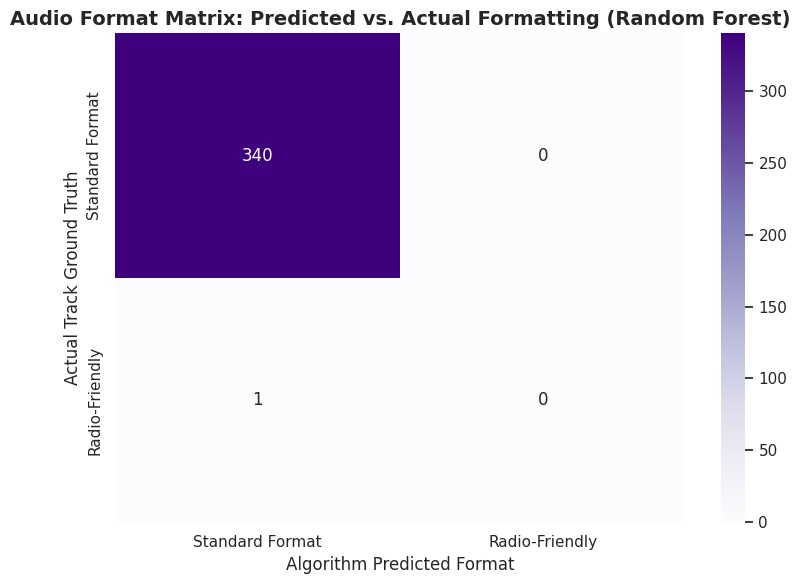


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


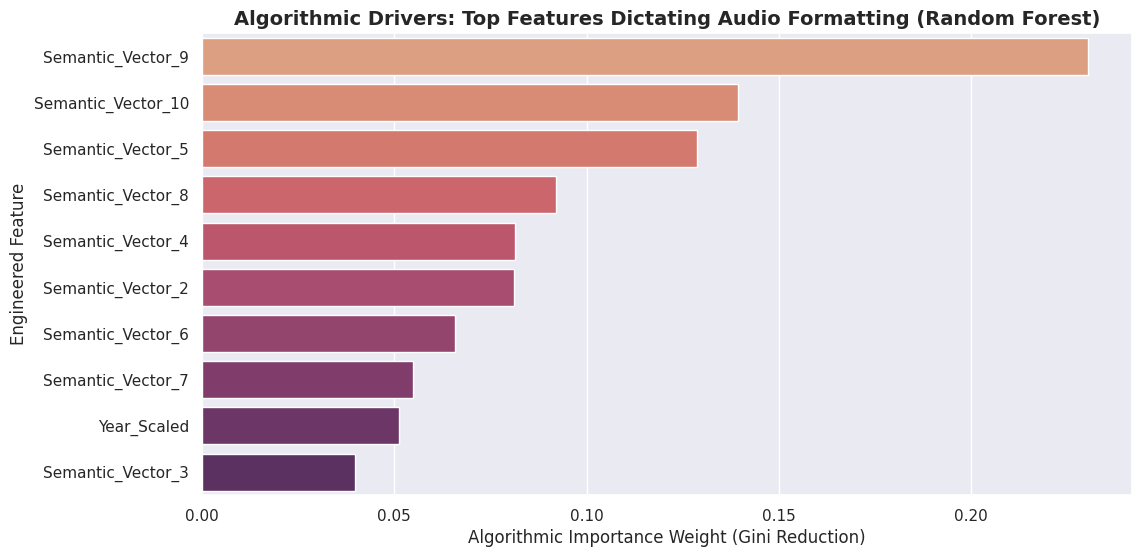

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")
# Split: 80% to train the algorithmic rules of the music industry,
# 20% to test true predictive power on unseen songs.

X_train, X_test, y_train, y_test = train_test_split(X_adv, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {len(X_train)} tracks")
print(f"Testing Set: {len(X_test)} tracks (Strictly Unseen)")


print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")
# 1. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost Classifier
scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]) if len(y_train[y_train == 1]) > 0 else 1
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("Both Classification Architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
# Force the algorithms to predict the unseen 20%
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n[{name} Performance Metrics]")
    print(f"   -> Precision: {prec * 100:.2f}% (Algorithmic reliability when predicting a Radio Hit)")
    print(f"   -> Recall:    {rec * 100:.2f}% (Capture rate of actual Radio Hits)")
    print(f"   -> F1-Score:  {f1 * 100:.2f}% (Harmonic mean of Precision and Recall)")
    return f1

f1_rf = evaluate_classifier("Random Forest", y_test, rf_preds)
print("-" * 40)
f1_xgb = evaluate_classifier("XGBoost", y_test, xgb_preds)

# Select the superior architecture based on the F1-Score
best_model_name = "XGBoost" if f1_xgb > f1_rf else "Random Forest"
best_preds = xgb_preds if f1_xgb > f1_rf else rf_preds
best_model = xgb_model if f1_xgb > f1_rf else rf_model

print(f"\nThe {best_model_name} mathematically outperformed the alternative in tracking streaming formats.")


print("\n--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---")
# The Confusion Matrix exposes the exact failure points of the algorithm.

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Standard Format', 'Radio-Friendly'],
            yticklabels=['Standard Format', 'Radio-Friendly'])
plt.title(f'Audio Format Matrix: Predicted vs. Actual Formatting ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm Predicted Format', fontsize=12)
plt.ylabel('Actual Track Ground Truth', fontsize=12)
plt.tight_layout()
plt.show()


print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")
# Let's open the black box. Does the Release Year matter more than the semantic text vectors?

importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='flare')
plt.title(f'Algorithmic Drivers: Top Features Dictating Audio Formatting ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You